# Human in the loop with LangGraph
- Notebook by Adam Lang
- Date: 8/10/2026

## Overview
- human in the loop lets you provide human oversite to the graph. 
- Docs: https://docs.langchain.com/oss/python/langchain/human-in-the-loop

In [2]:
## imports 
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END # entire graph of states and transitions
from langgraph.graph.message import add_messages # reducers -- adds messages to the graph



## imports 
import os
from dotenv import load_dotenv ## note: using GROQ_API_KEY from .env file for security reasons. Do not hardcode API keys in your code.

## init dotenv
load_dotenv()

True

In [3]:
import os
from langchain.chat_models import init_chat_model
llm=init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x1116630e0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x112521e80>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [4]:
## imports
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

## create State
class State(TypedDict):
    messages: Annotated[list, add_messages]


## set graph_builder
graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.
    
    return {"messages": [message]}


graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

In [5]:
## set memory
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

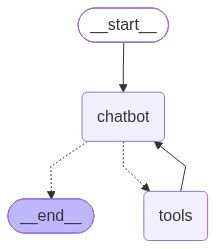

In [6]:
## visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


### User input

In [8]:
user_input = "I need some expert guidance and assistance for building AI agents. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building AI agents. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (2d0xyxeth)
 Call ID: 2d0xyxeth
  Args:
    query: I need help building AI agents, could you provide expert guidance and assistance?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (2d0xyxeth)
 Call ID: 2d0xyxeth
  Args:
    query: I need help building AI agents, could you provide expert guidance and assistance?


### Summary
- Now this is expecting human input, we need to build that.

In [ ]:
## setup human response
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()


================================== Ai Message ==================================
Tool Calls:
  human_assistance (cypc55kmb)
 Call ID: cypc55kmb
  Args:
    query: What is LangGraph?
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (zd0zdrx3w)
 Call ID: zd0zdrx3w
  Args:
    query: How does LangGraph work?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (zd0zdrx3w)
 Call ID: zd0zdrx3w
  Args:
    query: How does LangGraph work?


# Use Case example
- Lets say we had a radiology report and we wanted to generate an impression. 
- Lets say we wanted the human to provide human in the loop feedback and then regenerate. 
- The Radiology Gamuts Ontology contains causal links between thousands of imaging findings and potential causes. It is available through BioPortal, although anyone should review its CC BY-NC-ND licensing before production use: https://bioportal.bioontology.org/ontologies/GAMUTS
```
Dictated findings
      ↓
1. Parse + ground findings
      ↓
2. Radiology Gamuts lookup
      ↓
3. PubMed evidence search
      ↓
4. Generate impression
      ↓
5. Radiologist review
   ├─ Approve → Final
   ├─ Style correction → Save style rule → Regenerate
   └─ Clinical correction → Re-ground/research → Regenerate

```

## 1. State and reviewer context
- Keep study-specific information in graph state and cross-study style preferences in a LangGraph Store.

In [12]:
from dataclasses import dataclass
from typing import Any, TypedDict


@dataclass
class Context:
    radiologist_id: str


class RadiologyState(TypedDict, total=False):
    dictated_findings: str
    corrected_findings: str

    grounded_findings: list[dict[str, Any]]
    gamut_candidates: list[dict[str, Any]]
    pubmed_articles: list[dict[str, Any]]

    draft_impression: str
    approved_impression: str

    decision: str
    clinical_feedback: str
    style_feedback: str
    edited_impression: str
    remember_style: bool
    revision_number: int

## 2. Retrieval tools
- These tools should return structured data. 
- Do not let the language model generate citations from memory!

In [13]:
import os
import requests
from langchain_core.tools import tool


@tool
def ground_radiology_findings(findings: str) -> list[dict]:
    """
    Map dictated findings to controlled radiology concepts.

    Production implementation should also detect:
    - negation: "no pneumothorax"
    - uncertainty: "may represent"
    - temporality: acute versus chronic
    - anatomy and laterality
    - measurements
    """
    response = requests.get(
        "https://data.bioontology.org/annotator",
        headers={
            "Authorization": f"apikey token={os.environ['BIOPORTAL_API_KEY']}"
        },
        params={
            "text": findings,
            "ontologies": "GAMUTS,RADLEX",
            "longest_only": "true",
            "exclude_numbers": "false",
        },
        timeout=30,
    )
    response.raise_for_status()

    concepts = []

    for match in response.json():
        annotation = match["annotations"][0]
        concept = match["annotatedClass"]

        concepts.append({
            "text": annotation["text"],
            "start": annotation["from"],
            "end": annotation["to"],
            "concept_id": concept["@id"],
            "concept_url": concept["links"]["self"],
        })

    return concepts

Note:
-BioPortal documents its search, annotation, and ontology APIs, including API-key authentication. [BioPortal API documentation](https://data.bioontology.org/documentation)
- The gamuts lookup is best implemented as an adapter over a locally indexed/licensed RGO dataset:

In [14]:
@tool
def search_radiology_gamuts(
    grounded_findings: list[dict],
) -> list[dict]:
    """
    Query an indexed copy of RGO for may_be_caused_by relationships.

    Return objects such as:
    {
        "finding": "...",
        "candidate": "...",
        "relationship": "may_be_caused_by",
        "source": "RGO",
        "source_id": "RGO:..."
    }
    """
    return rgo_repository.find_differentials(grounded_findings)

Note: A basic PubMed tool can search and return source metadata:
- NCBI E-utilities are the official programmatic interface to PubMed. Include tool and email, respect rate limits, and display the NCBI disclaimer in a real application: https://www.ncbi.nlm.nih.gov/books/NBK25497/

In [15]:
@tool
def search_pubmed(query: str, max_results: int = 5) -> list[dict]:
    """Search PubMed and return real article metadata."""

    common = {
        "db": "pubmed",
        "tool": "radiology_evidence_agent",
        "email": os.environ["NCBI_EMAIL"],
    }

    if api_key := os.getenv("NCBI_API_KEY"):
        common["api_key"] = api_key

    search_response = requests.get(
        "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi",
        params={
            **common,
            "term": query,
            "retmode": "json",
            "retmax": max_results,
            "sort": "relevance",
        },
        timeout=30,
    )
    search_response.raise_for_status()

    pmids = search_response.json()["esearchresult"]["idlist"]

    if not pmids:
        return []

    summary_response = requests.get(
        "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi",
        params={
            **common,
            "id": ",".join(pmids),
            "retmode": "json",
        },
        timeout=30,
    )
    summary_response.raise_for_status()

    summaries = summary_response.json()["result"]

    return [
        {
            "pmid": pmid,
            "title": summaries[pmid].get("title"),
            "journal": summaries[pmid].get("fulljournalname"),
            "publication_date": summaries[pmid].get("pubdate"),
            "url": f"https://pubmed.ncbi.nlm.nih.gov/{pmid}/",
        }
        for pmid in pmids
    ]

## 3. Enforce tool order with grap nodes
-The model can construct the PubMed query, but the returned citations must come exclusively from the PubMed tool.


In [16]:
def ground_node(state: RadiologyState):
    findings = state.get("corrected_findings") or state["dictated_findings"]

    grounded = ground_radiology_findings.invoke({
        "findings": findings
    })

    return {"grounded_findings": grounded}


def gamut_node(state: RadiologyState):
    candidates = search_radiology_gamuts.invoke({
        "grounded_findings": state["grounded_findings"]
    })

    return {"gamut_candidates": candidates}


def pubmed_node(state: RadiologyState):
    query_response = llm.invoke([
        (
            "system",
            "Construct one concise PubMed search query. Return only the query."
        ),
        (
            "human",
            f"""
Grounded findings:
{state["grounded_findings"]}

RGO differential candidates:
{state["gamut_candidates"]}

Clinical correction:
{state.get("clinical_feedback", "")}
"""
        ),
    ])

    articles = search_pubmed.invoke({
        "query": query_response.content,
        "max_results": 5,
    })

    return {"pubmed_articles": articles}

## 4. Generate using evidence and stored style

In [17]:
from langgraph.runtime import Runtime


def generate_impression(
    state: RadiologyState,
    runtime: Runtime[Context],
):
    namespace = (
        runtime.context.radiologist_id,
        "radiology-impression-style",
    )

    stored = runtime.store.get(namespace, "profile")
    style_rules = stored.value.get("rules", []) if stored else []

    response = llm.invoke([
        (
            "system",
            """
Draft a radiology impression for radiologist review.

Rules:
- Use only the supplied findings.
- Do not convert a differential candidate into an asserted diagnosis.
- Do not invent citations.
- Use PMIDs only from the evidence packet.
- Separate the diagnostic impression from supporting evidence.
- The output remains a draft until approved.
"""
        ),
        (
            "human",
            f"""
FINDINGS:
{state.get("corrected_findings") or state["dictated_findings"]}

GROUNDED CONCEPTS:
{state["grounded_findings"]}

RGO CANDIDATES:
{state["gamut_candidates"]}

PUBMED EVIDENCE:
{state["pubmed_articles"]}

CLINICAL FEEDBACK:
{state.get("clinical_feedback", "")}

RADIOLOGIST STYLE RULES:
{style_rules}

PREVIOUS DRAFT:
{state.get("draft_impression", "")}
"""
        ),
    ])

    return {
        "draft_impression": response.content,
        "revision_number": state.get("revision_number", 0) + 1,
    }

## 5. Human review
- Use structured feedback so clinical corrections and stylistic preferences are handled differently.

In [18]:
from langgraph.types import interrupt


def human_review(state: RadiologyState):
    review = interrupt({
        "task": "review_radiology_impression",
        "findings": state["dictated_findings"],
        "grounded_findings": state["grounded_findings"],
        "differential_candidates": state["gamut_candidates"],
        "pubmed_articles": state["pubmed_articles"],
        "draft_impression": state["draft_impression"],
        "revision_number": state["revision_number"],
        "response_schema": {
            "decision": "approve | revise_style | revise_clinical | revise_both",
            "style_feedback": "optional generalized style correction",
            "clinical_feedback": "optional clinical correction",
            "corrected_findings": "optional corrected source findings",
            "edited_impression": "optional human-edited version",
            "remember_style": "boolean",
        },
    })

    return review

## 6. Learn style without memorizing reports
- Save generalized preferences—not the report, findings, patient identifiers, or diagnoses.
- A LangGraph Store is the correct mechanism here because it persists preferences across separate study threads. The checkpointer preserves one case; the Store preserves radiologist-specific preferences across cases: https://docs.langchain.com/oss/python/langchain/long-term-memory

In [19]:
def learn_style(
    state: RadiologyState,
    runtime: Runtime[Context],
):
    if not state.get("remember_style"):
        return {}

    namespace = (
        runtime.context.radiologist_id,
        "radiology-impression-style",
    )

    existing = runtime.store.get(namespace, "profile")
    existing_rules = existing.value.get("rules", []) if existing else []

    extraction = llm.with_structured_output(
        # Replace with a Pydantic model in production
        dict
    ).invoke([
        (
            "system",
            """
Extract only reusable writing preferences.

Do not store:
- patient information
- specific diagnoses
- measurements
- anatomy unique to this case
- complete report text
"""
        ),
        (
            "human",
            f"""
Existing rules:
{existing_rules}

Original draft:
{state["draft_impression"]}

Human-edited version:
{state.get("edited_impression", "")}

Explicit style feedback:
{state.get("style_feedback", "")}

Return:
{{"rules": ["generalized rule 1", "generalized rule 2"]}}
"""
        ),
    ])

    runtime.store.put(
        namespace,
        "profile",
        {"rules": extraction["rules"]},
    )

    return {}

## 7. Assemble the graph

In [20]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.store.memory import InMemoryStore


def review_route(state: RadiologyState):
    return state["decision"]


def after_style_learning(state: RadiologyState):
    if state["decision"] == "revise_both":
        return "ground"
    return "generate"


builder = StateGraph(RadiologyState, context_schema=Context)

builder.add_node("ground", ground_node)
builder.add_node("gamuts", gamut_node)
builder.add_node("pubmed", pubmed_node)
builder.add_node("generate", generate_impression)
builder.add_node("review", human_review)
builder.add_node("learn_style", learn_style)

builder.add_edge(START, "ground")
builder.add_edge("ground", "gamuts")
builder.add_edge("gamuts", "pubmed")
builder.add_edge("pubmed", "generate")
builder.add_edge("generate", "review")

builder.add_conditional_edges(
    "review",
    review_route,
    {
        "approve": END,
        "revise_style": "learn_style",
        "revise_clinical": "ground",
        "revise_both": "learn_style",
    },
)

builder.add_conditional_edges(
    "learn_style",
    after_style_learning,
    {
        "ground": "ground",
        "generate": "generate",
    },
)

graph = builder.compile(
    checkpointer=InMemorySaver(),
    store=InMemoryStore(),
)

### Invoke and revise usine same thread case

In [ ]:
config = {"configurable": {"thread_id": "synthetic-study-001"}}
context = Context(radiologist_id="radiologist-001")

paused = graph.invoke(
    {
        "dictated_findings": synthetic_dictation,
        "revision_number": 0,
    },
    config=config,
    context=context,
)

revised = graph.invoke(
    Command(resume={
        "decision": "revise_both",
        "clinical_feedback": "Do not call this definite pneumonia.",
        "style_feedback": "Keep the impression to two numbered items.",
        "corrected_findings": synthetic_dictation,
        "edited_impression": "Human-edited example here",
        "remember_style": True,
    }),
    config=config,
    context=context,
)

NOTE:
- For production, the remaining important pieces are negation-aware parsing, local/licensed RGO indexing, PubMed abstract retrieval and evidence scoring, durable Postgres persistence, source snapshots for auditing, PHI controls, and prospective clinical validation. 
- The model should propose—not determine—the differential or final impression.